<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Projective_Dynamics_and_the_Emergence_of_Quantum_Wave_Equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

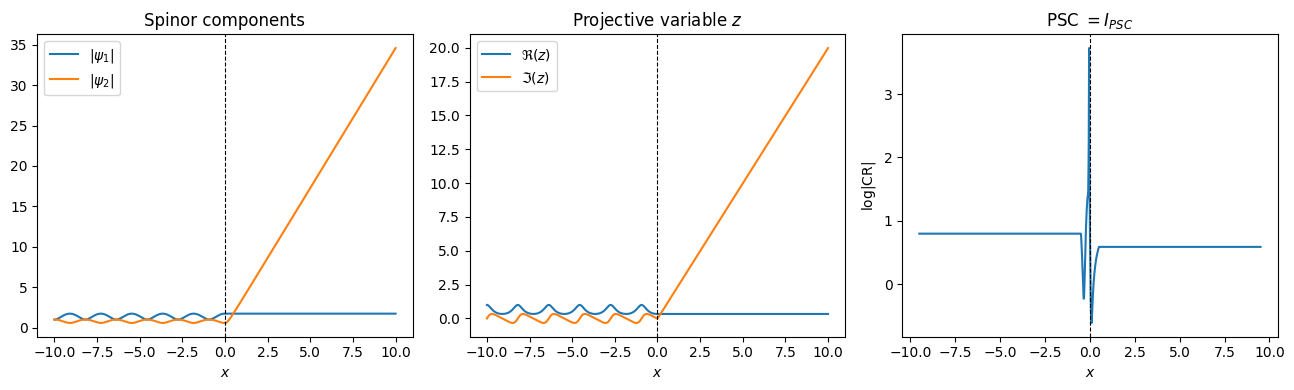

In [2]:
# %% [markdown]
# 📓 Projective Structure Content (PSC) in Dirac Dynamics
#
# This notebook computes the Projective Structure Content (PSC)
# for a 1D Dirac system with a step potential.
#
# All quantities are expressed in natural units:
# ℏ = c = m = 1
#
# We:
# - Solve the Dirac equation numerically (RK4)
# - Construct the projective variable z = ψ₂ / ψ₁
# - Compute the cross-ratio (PSC)
# - Visualize the structure across a potential discontinuity


# %%
import numpy as np
import matplotlib.pyplot as plt


# %% [markdown]
# ## ⚙️ Parameters


# %%
hbar, c, m = 1.0, 1.0, 1.0
E, V0 = 2.0, 3.0

def V(x):
    return 0.0 if x < 0 else V0


# %% [markdown]
# ## 🔷 Dirac RHS (Equations 14a–14b)


# %%
def rhs(x, psi):
    p1, p2 = psi
    Ep = E - V(x)

    dp1 = -1j*(m*c**2 + Ep)/(hbar*c) * p2
    dp2 =  1j*(m*c**2 - Ep)/(hbar*c) * p1

    return np.array([dp1, dp2])


# %% [markdown]
# ## 🔷 RK4 Integrator


# %%
def integrate(xs, psi0):
    psi = np.zeros((len(xs), 2), dtype=complex)
    psi[0] = psi0

    dx = xs[1] - xs[0]

    for i in range(len(xs)-1):
        k1 = rhs(xs[i],        psi[i])
        k2 = rhs(xs[i]+dx/2,   psi[i]+dx*k1/2)
        k3 = rhs(xs[i]+dx/2,   psi[i]+dx*k2/2)
        k4 = rhs(xs[i]+dx,     psi[i]+dx*k3)

        psi[i+1] = psi[i] + dx*(k1 + 2*k2 + 2*k3 + k4)/6

    return psi


# %% [markdown]
# ## 🔷 Cross-Ratio (Equation 26)


# %%
def cross_ratio(z1, z2, z3, z4):
    return ((z1 - z3)*(z2 - z4)) / ((z1 - z4)*(z2 - z3))


# %% [markdown]
# ## 🔷 Simulation


# %%
x = np.linspace(-10, 10, 2000)

#psi = integrate(x, np.array([1+0j, 0.5+0j]))
psi = integrate(x, np.array([1+0j, 1.0+0j]))
psi1 = psi[:, 0]
psi2 = psi[:, 1]

# Projective variable
z = psi2 / psi1


# %% [markdown]
# ## 🔷 PSC Computation (Sliding Cross-Ratio Window)


# %%
d1, d2 = 10, 50

psc = []
for i in range(d2, len(z)-d2):
    chi = cross_ratio(z[i-d2], z[i-d1], z[i+d1], z[i+d2])
    psc.append(np.log(np.abs(chi) + 1e-15))

psc = np.array(psc)
xpsc = x[d2:len(z)-d2]


# %% [markdown]
# ## 📊 Results


# %%
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Spinor components
axes[0].plot(x, np.abs(psi1), label=r'$|\psi_1|$')
axes[0].plot(x, np.abs(psi2), label=r'$|\psi_2|$')
axes[0].axvline(0, ls='--', color='k', lw=0.8)
axes[0].set(xlabel='$x$', title='Spinor components')
axes[0].legend()

# Projective variable
axes[1].plot(x, np.real(z), label=r'$\Re(z)$')
axes[1].plot(x, np.imag(z), label=r'$\Im(z)$')
axes[1].axvline(0, ls='--', color='k', lw=0.8)
axes[1].set(xlabel='$x$', title='Projective variable $z$')
axes[1].legend()

# PSC
axes[2].plot(xpsc, psc)
axes[2].axvline(0, ls='--', color='k', lw=0.8)
axes[2].set(
    xlabel='$x$',
    ylabel=r'$\log|\mathrm{CR}|$',
    title='PSC $= I_{PSC}$'
)

plt.tight_layout()
plt.savefig('psc_dirac_step.pdf', dpi=150)
plt.show()


# %% [markdown]
# ## 🔬 Interpretation
#
# - PSC is approximately constant within each region
# - Smooth variation occurs near x = 0 (potential step)
#
# 👉 This suggests:
#     Projective structure propagates across discontinuities
#     even when energy conditions change
#
# 🔥 Key Insight:
#     Structure (PSC) is an additional physical descriptor
#     beyond energy and amplitude